In [1]:
from tqdm import tqdm

In [2]:
import pandas as pd
from pathlib import Path
import os

DATA_DIR = Path.cwd() / "Emotion_Dataset_Indo_English"

print("Using data from:", DATA_DIR)

csv_files = [f for f in os.listdir(DATA_DIR)]

eng_df = []
dfs_other = []

for file in csv_files:
    path = os.path.join(DATA_DIR, file)

    if file == "text.csv":
        df = pd.read_csv(path)
        df = df[df["label"] != 5]
        df = df.drop(columns=["Unnamed: 0"])
        eng_df = df.groupby("label").sample(n=500).reset_index(drop=True)

        label_map = {
            0: "sad",
            1: "joy",
            2: "love",
            3: "anger",
            4: "fear"
        }
    
        eng_df["label"] = eng_df["label"].map(label_map)
    else:
        indo_df_emo = pd.read_csv(path, sep="\t",skiprows=1, header=None)
        indo_df_emo = indo_df_emo.sample(n=500).reset_index(drop=True)
        dfs_other.append(indo_df_emo)
        
indo_df = pd.concat(dfs_other, ignore_index=True)
indo_df.columns = ['tweet', 'label']
indo_df["label"] = indo_df["label"].str.lower()

Using data from: /Users/GraceCeline/Downloads/Emotion_Classification/Emotion_Dataset_Indo_English


In [3]:
indo_df.head()

,tweet,label
0,"baik banget, baiknya juga ke semua orang. mana...",love
1,"gemes banget.. you too cantik! anyway, kamu kl...",love
2,suka banget ama exooo,love
3,suka banget dong gw,love
4,kasih ak aja ak suka sm coklat,love


## MarFin Emotion

In [4]:
import torch

from transformers import pipeline,AutoTokenizer, AutoModelForSequenceClassification

classifier = pipeline("zero-shot-classification", model="MarfinF/marfin_emotion")

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

In [5]:
text = "seru bgt dapet 10 juta"
labels = ["joy", "sad", "anger", "fear", "love"]
result = classifier(text, labels)

print(result)

{'sequence': 'seru bgt dapet 10 juta', 'labels': ['fear', 'anger', 'sad', 'joy', 'love'], 'scores': [0.3752540051937103, 0.23751945793628693, 0.19851236045360565, 0.12371747940778732, 0.06499667465686798]}


In [6]:
label_list_id = []
indo_labels = ["senang", "sedih", "marah", "takut", "cinta"]
for tweet in tqdm(indo_df["tweet"].tolist()):
    result = classifier(tweet, indo_labels)
    label_list_id.append(result["labels"][0])

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2500/2500 [42:46<00:00,  1.03s/it]


In [7]:
import numpy as np
from sklearn.metrics import accuracy_score

emotion_map = {
    "senang": "joy",
    "sedih": "sad",
    "marah": "anger",
    "takut": "fear",
    "cinta": "love"
}

label_id_marfin = [emotion_map.get(x, "unknown") for x in label_list_id]


accuracy_id_marfin = accuracy_score(indo_df["label"], label_id_marfin)
print("Accuracy:", accuracy_id_marfin)

Accuracy: 0.616


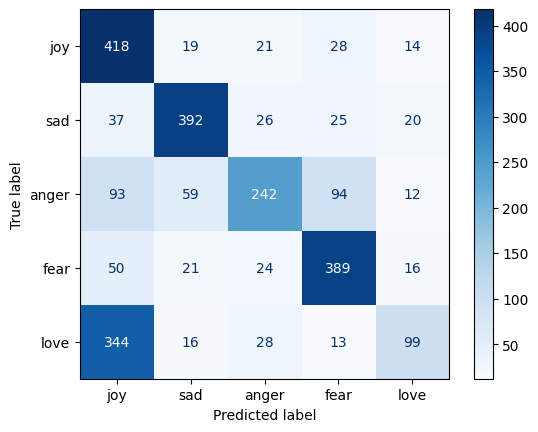

In [8]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm_id_marfin = confusion_matrix(indo_df["label"], label_id_marfin, labels=labels)
disp_id_marfin = ConfusionMatrixDisplay(confusion_matrix=cm_id_marfin, display_labels=labels)

disp_id_marfin.plot(cmap="Blues", colorbar=True)
plt.show()

In [9]:
label_en_marfin = []
en_labels = ["joy", "sad", "anger", "fear", "love"]
for tweet in tqdm(eng_df["text"].tolist()):
    result = classifier(tweet, en_labels)
    label_en_marfin.append(result["labels"][0])

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2500/2500 [08:33<00:00,  4.87it/s]


In [10]:
accuracy_en_marfin = accuracy_score(eng_df["label"], label_en_marfin)
print("Accuracy:", accuracy_en_marfin)

Accuracy: 0.5436


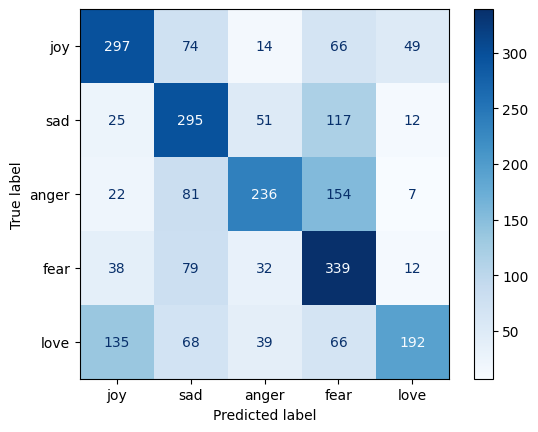

In [11]:
cm_en_marfin = confusion_matrix(eng_df["label"], label_en_marfin, labels=labels)
disp_en_marfin = ConfusionMatrixDisplay(confusion_matrix=cm_en_marfin, display_labels=labels)

disp_en_marfin.plot(cmap="Blues", colorbar=True)
plt.show()

## LLaMA 3.1 Instruct

In [ ]:
import os


In [14]:
from openai import OpenAI

client = OpenAI(
    base_url="https://router.huggingface.co/v1",
    api_key=os.environ["HF_TOKEN"],
)

In [16]:
# Copied from inference providers, check if connection with client exists
completion = client.chat.completions.create(
    model="meta-llama/Llama-3.1-8B-Instruct:novita",
    messages=[
        {
            "role": "user",
            "content": "What is the capital of France?"
        }
    ],
)

print(completion.choices[0].message)

ChatCompletionMessage(content='The capital of France is Paris.', refusal=None, role='assistant', annotations=None, audio=None, function_call=None, tool_calls=None)


In [17]:
def build_prompt_en(sentence):
    return (
        "Task: classify the emotion of the sentence.\n\n"
        f"Sentence: {sentence}\n\n"
        "Rules:\n"
        "- Output exactly ONE word\n"
        "- No explanation\n"
        "- Choose from: joy, sad, anger, fear, love\n\n"
        "Answer:"
    )


def build_prompt_id(sentence):
    return (
        "Klasifikasikan emosi dari kalimat di bawah ini.\n\n"
        f"Kalimat: {sentence}\n\n"
        "Label yang diperbolehkan (output SATU kata saja):\n"
        "senang, sedih, marah, takut, cinta\n"
        "Jawaban:"
    )



In [18]:
LABELS = ["joy", "sad", "anger", "fear", "love", "senang", "sedih", "marah", "takut", "cinta"]

def classify_sentence(sentence, language):
    message = ""
    if language == "en":
        message = build_prompt_en(sentence)
    if language == "id":
        message = build_prompt_id(sentence)
        
    response = client.responses.create(
        model="meta-llama/Llama-3.1-8B-Instruct",
        input=message,
        temperature=0,
        top_p=1.0,
    )
    output = response.output_text.lower()
    
    return next((l for l in LABELS if l.lower() in output), "invalid")


In [20]:
response = client.responses.create(
        model="meta-llama/Llama-3.1-8B-Instruct",
        input="Task: classify the emotion of the sentence.\n\n"
                "I am very sad today"
                "Rules:\n"
                "- Output exactly ONE word\n"
                "- No explanation\n"
                "- Choose from: joy, sad, anger, fear, love\n\n"
                "Answer:",
        temperature=0,
        top_p=1.0,
    )

In [21]:
response.output_text

'sad'

In [23]:
from tqdm import tqdm
import time

label_en_llama = []

for tweet in tqdm(eng_df["text"].tolist()):
    label = classify_sentence(tweet, "en")
    label_en_llama.append(label.lower())

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2500/2500 [08:45<00:00,  4.75it/s]


In [24]:
accuracy_en_llama = accuracy_score(eng_df["label"], label_en_llama)
print(accuracy_en_llama)

0.0336


In [25]:
label_id_llama = []

for tweet in tqdm(indo_df["tweet"].tolist()):
    label = classify_sentence(tweet, "id")
    label_id_llama.append(label)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2500/2500 [09:12<00:00,  4.52it/s]


In [27]:
emotion_map = {
    "senang": "joy",
    "sedih": "sad",
    "marah": "anger",
    "takut": "fear",
    "cinta": "love"
}

In [28]:
label_id_llama = [emotion_map.get(x, "unknown") for x in label_id_llama]

In [29]:
accuracy_id_llama = accuracy_score(indo_df["label"], label_id_llama)
print(accuracy_id_llama)

0.0324


In [30]:
few_shot_examples_en = [
    ("I am so happy to see you again!", "joy"),
    ("I miss you so much it hurts", "sad"),
    ("I can't believe you did that, I'm furious", "anger"),
    ("I'm scared of what might happen next", "fear"),
    ("You mean everything to me", "love"),
]

few_shot_examples_id = [
    ("Seneng banget bisa ketemu lagi sama kamu!", "senang"),
    ("Kangen banget sama kamu, rasanya sakit", "sedih"),
    ("Ga nyangka kamu lakuin itu, aku marah banget", "marah"),
    ("Aku takut sama apa yang bakal terjadi", "takut"),
    ("Kamu segalanya buat aku", "cinta"),
]

def build_prompt_en_fewshot(sentence, ex_amount, examples=few_shot_examples_en):
    prompt = "Task: classify the emotion of the sentence.\n\n"
    prompt += "Rules:\n"
    prompt += "- Output exactly ONE word\n"
    prompt += "- No explanation\n"
    prompt += "- Choose from: joy, sad, anger, fear, love\n\n"
    prompt += "Examples:\n"
    examples = examples[:ex_amount]
    for ex_sentence, ex_label in examples:
        prompt += f"Sentence: {ex_sentence}\nAnswer: {ex_label}\n\n"
    prompt += f"Sentence: {sentence}\nAnswer:"
    return prompt

def build_prompt_id_fewshot(sentence, ex_amount, examples=few_shot_examples_id):
    prompt = "Klasifikasikan emosi dari kalimat di bawah ini.\n\n"
    prompt += "Label yang diperbolehkan (output SATU kata saja):\n"
    prompt += "senang, sedih, marah, takut, cinta\n\n"
    prompt += "Contoh:\n"
    examples = examples[:ex_amount]
    for ex_sentence, ex_label in examples:
        prompt += f"Kalimat: {ex_sentence}\nJawaban: {ex_label}\n\n"
    prompt += f"Kalimat: {sentence}\nJawaban:"
    return prompt

In [31]:
def classify_sentence_fewshot(sentence, language, ex_amount):
    message = ""
    if language == "en":
        message = build_prompt_en_fewshot(sentence, ex_amount)
    if language == "id":
        message = build_prompt_id_fewshot(sentence, ex_amount)
        
    response = client.responses.create(
        model="meta-llama/Llama-3.1-8B-Instruct",
        input=message,
        temperature=0,
        top_p=1.0,
    )
    output = response.output_text.lower()
    
    return next((l for l in LABELS if l.lower() in output), "invalid")

In [32]:
from tqdm import tqdm
import time

label_en_llama_3shot = []

for tweet in tqdm(eng_df["text"].tolist()):
    label = classify_sentence_fewshot(tweet, "en", 3)
    label_en_llama_3shot.append(label.lower())

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2500/2500 [09:57<00:00,  4.18it/s]


In [33]:
from sklearn.metrics import accuracy_score
accuracy_en_llama_3shot = accuracy_score(eng_df["label"], label_en_llama_3shot)
print(accuracy_en_llama_3shot)

0.038


In [34]:
label_id_llama_3shot = []

for tweet in tqdm(indo_df["tweet"].tolist()):
    label = classify_sentence_fewshot(tweet, "id", 3)
    label_id_llama_3shot.append(label)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2500/2500 [12:10<00:00,  3.42it/s]


In [35]:
label_id_llama_3shot = [emotion_map.get(x, "unknown") for x in label_id_llama_3shot]
accuracy_id_llama_3shot = accuracy_score(indo_df["label"], label_id_llama_3shot)
print(accuracy_id_llama_3shot)

0.0556


In [36]:
label_en_llama_5shot = []

for tweet in tqdm(eng_df["text"].tolist()):
    label = classify_sentence_fewshot(tweet, "en", 5)
    label_en_llama_5shot.append(label.lower())

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2500/2500 [09:16<00:00,  4.49it/s]


In [37]:
accuracy_en_llama_5shot = accuracy_score(eng_df["label"], label_en_llama_5shot)
print(accuracy_en_llama_5shot)

0.0316


In [40]:
label_id_llama_5shot = []

for tweet in tqdm(indo_df["tweet"].tolist()):
    label = classify_sentence_fewshot(tweet, "id", 5)
    label_id_llama_5shot.append(label)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2500/2500 [13:32<00:00,  3.08it/s]


In [41]:
label_id_llama_5shot = [emotion_map.get(x, "unknown") for x in label_id_llama_5shot]
accuracy_id_llama_5shot = accuracy_score(indo_df["label"], label_id_llama_5shot)
print(accuracy_id_llama_5shot)

0.0552


## BERT base uncased

In [25]:
from transformers import pipeline

classifier = pipeline("text-classification",model='bhadresh-savani/bert-base-uncased-emotion', return_all_scores=True)
prediction = classifier("I love using transformers. The best part is wide range of support and its easy to use", )
print(prediction)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bhadresh-savani/bert-base-uncased-emotion
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[{'label': 'joy', 'score': 0.9972521662712097}]


In [26]:
def extract_label(text, result):
    result = classifier(text, return_all_scores=True)
    # scores = result[0]
    best_label = result[0]["label"]

    if best_label == "sadness":
        best_label = "sad"

    return best_label


In [27]:
label_en_bert = []
en_labels = ["joy", "sad", "anger", "fear", "love"]
for tweet in tqdm(eng_df["text"].tolist()):
    result = extract_label(tweet, en_labels)
    label_en_bert.append(result)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2500/2500 [00:49<00:00, 50.30it/s]


In [28]:
accuracy_en_bert = accuracy_score(eng_df["label"], label_en_bert)
print(accuracy_en_bert)

0.926


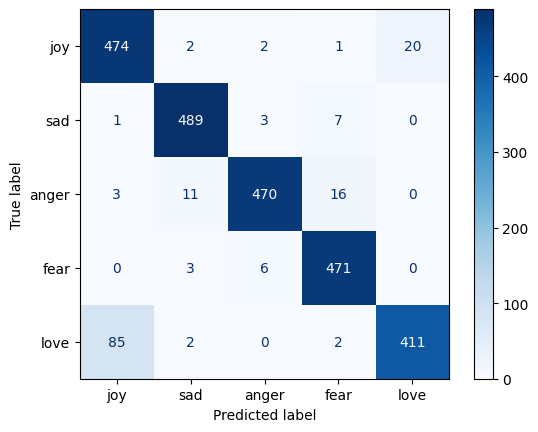

In [29]:
cm_en_bert = confusion_matrix(eng_df["label"], label_en_bert, labels=labels)
disp_en_bert = ConfusionMatrixDisplay(confusion_matrix=cm_en_bert, display_labels=labels)

disp_en_bert.plot(cmap="Blues", colorbar=True)
plt.show()

In [30]:
label_id_bert = []
id_labels = ["senang", "sedih", "marah", "takut", "cinta"]
for tweet in tqdm(indo_df["tweet"].tolist()):
    result = extract_label(tweet, id_labels)
    label_id_bert.append(result)


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2500/2500 [01:04<00:00, 38.49it/s]


In [31]:
accuracy_id_bert = accuracy_score(indo_df["label"], label_id_bert)
print(accuracy_id_bert)

0.2192


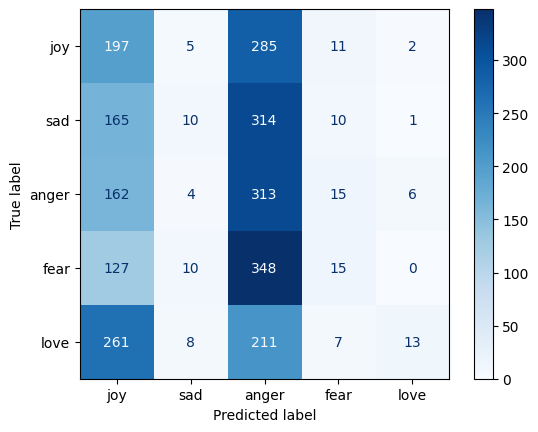

In [32]:
cm_id_bert = confusion_matrix(indo_df["label"], label_id_bert, labels=labels)
disp_id_bert = ConfusionMatrixDisplay(confusion_matrix=cm_id_bert, display_labels=labels)

disp_id_bert.plot(cmap="Blues", colorbar=True)
plt.show()

# Remove HF Token - AI generated code

In [1]:
import nbformat

nb = nbformat.read("emotion-detection-2.ipynb", as_version=4)

def clean_text(text):
    if isinstance(text, str):
        return text.replace("REMOVED", "REMOVEDREDACTED_")
    return text

for cell in nb.cells:
    # clean source
    cell.source = clean_text(cell.source)
    
    # clean outputs
    if "outputs" in cell:
        for output in cell["outputs"]:
            if "text" in output:
                output["text"] = clean_text("".join(output["text"]))
            if "data" in output:
                for k in output["data"]:
                    if isinstance(output["data"][k], list):
                        output["data"][k] = [clean_text(x) for x in output["data"][k]]
                    elif isinstance(output["data"][k], str):
                        output["data"][k] = clean_text(output["data"][k])

nbformat.write(nb, "emotion-detection-2.ipynb")